<a href="https://colab.research.google.com/github/AnuragKamblekar/Interncodes/blob/main/flac%20to%20wav%20conversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Conversion complete: /content/Symphony No.6 (1st movement).wav


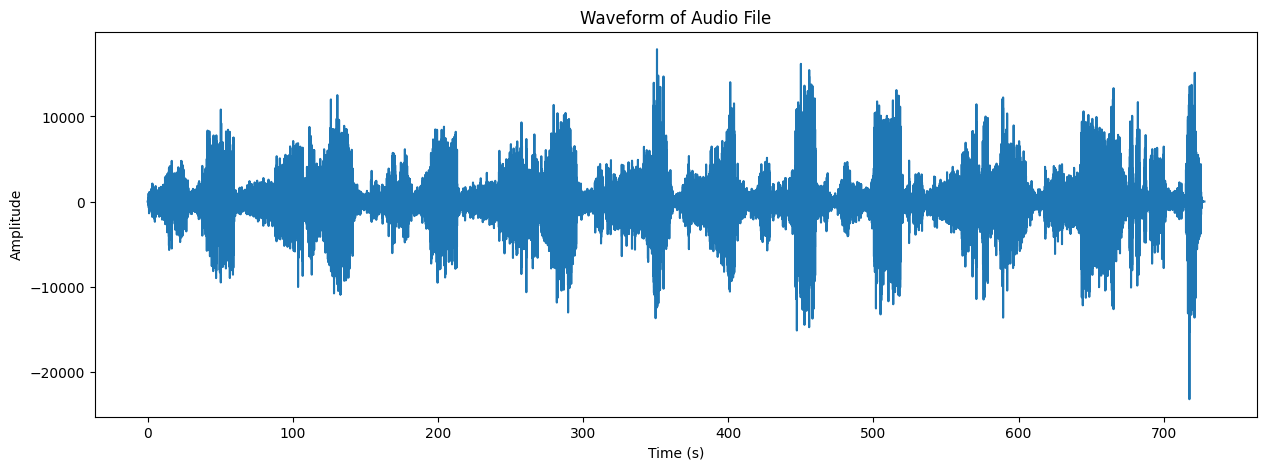

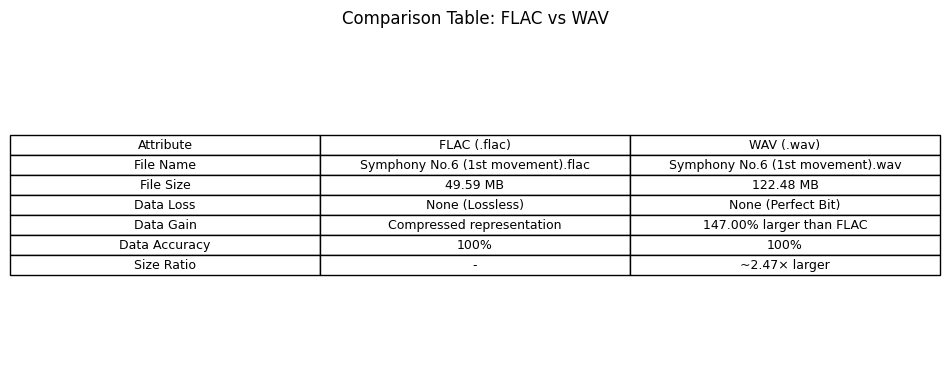

In [2]:
import os
import wave
from pydub import AudioSegment
import matplotlib.pyplot as plt
import numpy as np
import wave

class Fileconversion:
    def __init__(self, inputpath, outputpath=None):
        self.inputpath = inputpath
        if outputpath is None:
            base, _ = os.path.splitext(inputpath)
            outputpath = base + ".wav"
        self.outputpath = outputpath
        self.audio = None

    def convert(self):
        self.audio = AudioSegment.from_file(self.inputpath, format="flac")
        self.audio.export(self.outputpath, format="wav")
        print(f"Conversion complete: {self.outputpath}")
        flacsize = os.path.getsize(self.inputpath)
        wavsize = os.path.getsize(self.outputpath)


    def visualize(self):
        wavobject = wave.open(self.outputpath, 'r')
        samplefrequency = wavobject.getframerate()
        numberofsamples = wavobject.getnframes()
        numberofchannels = wavobject.getnchannels()
        taudio = numberofsamples / samplefrequency

        signalwave = wavobject.readframes(numberofsamples)
        wavobject.close()

        singalarray = np.frombuffer(signalwave, dtype=np.int16)

        if numberofchannels == 2:
            singalarray = singalarray.reshape(-1, 2)
            singalarray = singalarray[:, 0]

        maxpoints = 100000
        if len(singalarray) > maxpoints:
            step = len(singalarray) // maxpoints
            singalarray = singalarray[::step]
            times = np.linspace(0, taudio, num=len(singalarray))
        else:
            times = np.linspace(0, taudio, num=len(singalarray))

        plt.figure(figsize=(15, 5))
        plt.plot(times, singalarray)
        plt.title("Waveform of Audio File")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.show()

    def visualizetable(self):
        flacsize = os.path.getsize(self.inputpath) / 1024 / 1024
        wavsize = os.path.getsize(self.outputpath) / 1024 / 1024
        datagainpercentage = ((wavsize - flacsize) / flacsize) * 100
        ratio = wavsize / flacsize

        if self.inputpath.lower().endswith(".flac"):
            flacloss = "None (Lossless)"
        else:
            flacloss = "Unknown"

        if self.outputpath.lower().endswith(".wav"):
            wavloss = "None (Perfect Bit)"
        else:
            wavloss = "Unknown"

        tabledata = [
            ["File Name", os.path.basename(self.inputpath), os.path.basename(self.outputpath)],
            ["File Size", f"{flacsize:.2f} MB", f"{wavsize:.2f} MB"],
            ["Data Loss", flacloss,wavloss],
            ["Data Gain", "Compressed representation", f"{datagainpercentage:.2f}% larger than FLAC"],
            ["Data Accuracy", "100%", "100%"],
            ["Size Ratio", "-", f"~{ratio:.2f}× larger"]
        ]

        fig, ax = plt.subplots(figsize=(10,4))
        ax.axis('off')
        table = ax.table(cellText=tabledata,
                         colLabels=["Attribute", "FLAC (.flac)", "WAV (.wav)"],
                         loc='center',
                         cellLoc='center')
        table.auto_set_font_size(True)
        table.scale(1.2,1.2)
        plt.title("Comparison Table: FLAC vs WAV", fontsize=12, pad=20)
        plt.show()

if __name__ == "__main__":
    inputflac = "/content/Symphony No.6 (1st movement).flac"
    converter = Fileconversion(inputflac)
    converter.convert()
    converter.visualize()
    converter.visualizetable()
